## Baking subreddit analysis
This notebook analyzes what people are posting on the r/baking subreddit, through the lens of GBBO episode technical challenges and air dates.

Hypothesis: After a GBBO episode airs, more people are baking based off of that week's Technical Challenge.

The starting data for analysis is 'GBBO_reddit_posts_merged.csv'

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime, timezone
import matplotlib.pyplot as plt
import re
from scipy import stats

In [2]:
#load the data
reddit_baking_all_posts = pd.read_csv('/Users/rachelvice/Development/Lede/Projects/bakeoff_effect/data/baking_reddit_data_complete.csv')

reddit_gbbo_technical_posts = pd.read_csv('/Users/rachelvice/Development/Lede/Projects/bakeoff_effect/data/GBBO_reddit_posts_merged.csv')
reddit_gbbo_technical_posts.head()

,bakeoff_match,bakeoff_score,Airdate,Season,Episode,Theme,Signature,Signature Time (min),Technical,Technical Time (min),Showstopper,Showstopper Time (min),challenge level numeric,reddit_post_title,reddit_post_date,days_since_air
0,red velvet cake,90.32258,2022-09-13,13,1,cake,12 mini sandwich cakes,120.0,red velvet cake,120.0,3d cake home,240.0,2.0,Red velvet cake?,2011-04-12,4172 days
1,english muffins,80.00000,2013-08-27,4,2,bread,36 breadsticks,120.0,english muffins,165.0,decorative loaf,240.0,NaN,I made English muffins!!,2011-07-20,769 days
2,chocolate teacakes,78.78788,2012-10-02,3,8,biscuit,48 crackers,120.0,chocolate teacakes,120.0,gingerbread structure,240.0,2.0,Chocolate cake,2012-01-15,261 days
3,chocolate teacakes,78.78788,2012-10-02,3,8,biscuit,48 crackers,120.0,chocolate teacakes,120.0,gingerbread structure,240.0,2.0,Chocolate cake,2012-01-15,261 days
4,red velvet cake,80.00000,2022-09-13,13,1,cake,12 mini sandwich cakes,120.0,red velvet cake,120.0,3d cake home,240.0,2.0,Red Velvet Cake,2012-02-19,3859 days


In [3]:
dated_reddit_csv = Path("/Users/rachelvice/Development/Lede/Projects/bakeoff_effect/data/reddit_baking_all_posts_dated.csv")
if dated_reddit_csv.is_file():
    reddit_baking_all_posts_dated = pd.read_csv(dated_reddit_csv)
    print(f"file already exists")
else:
    reddit_baking_all_posts['date'] = pd.to_datetime(reddit_baking_all_posts['created_utc'], unit='s')
    reddit_baking_all_posts['date'] = reddit_baking_all_posts['date'].dt.strftime('%m/%d/%Y')
    reddit_baking_all_posts_dated = reddit_baking_all_posts.drop(columns=['created_utc', 'Unnamed: 0'])

    reddit_baking_all_posts_dated.to_csv('reddit_baking_all_posts_dated.csv')

file already exists


In [4]:
reddit_baking_all_posts_dated

,Unnamed: 0,thumbnail,title,url,date
0,0,NaN,"Come to Cupcake Camp OC, tomorrow. Eat tons of...",http://i2.photobucket.com/albums/y6/Eunmi429/c...,08/01/2010
1,1,NaN,My junior's cheesecake woes... any advice appr...,http://imgur.com/hBJlw,08/04/2010
2,2,default,Chocolate Cake with Chocolate Peanut Butter Fr...,http://blog.junbelen.com/2010/02/07/how-to-mak...,08/04/2010
3,3,default,First Attempt at White Bread,https://www.reddit.com/r/Baking/comments/cxey3...,08/04/2010
4,4,self,HELP -- Pastry Cream Butter Cream is BROKEN,https://www.reddit.com/r/Baking/comments/cxl68...,08/05/2010
...,...,...,...,...,...
528981,528981,https://preview.redd.it/h4f9b1gy1oeh1.jpg?widt...,Self Developed Recipe! Walnut Shortbread brown...,https://www.reddit.com/gallery/1v2ypjc,07/21/2026
528982,528982,default,Biscuits à la Sally,NaN,07/21/2026
528983,528983,https://preview.redd.it/99ko9rg34oeh1.jpeg?wid...,Biscuits à la Sally,https://i.redd.it/99ko9rg34oeh1.jpeg,07/21/2026
528984,528984,https://preview.redd.it/qj3eujca4oeh1.jpg?widt...,"Low k screwed up the lattice , but it still lo...",https://www.reddit.com/gallery/1v2z0qo,07/21/2026


In [5]:
#calculating denominator for normalization - how many posts are there per day in the r/baking subreddit
r_baking_post_counts = reddit_baking_all_posts_dated['date'].value_counts().to_frame()
r_baking_post_counts = r_baking_post_counts.reset_index()
r_baking_post_counts.to_csv('r_baking_total_post_counts.csv')
r_baking_post_counts

,date,count
0,04/12/2020,627
1,05/10/2020,510
2,12/25/2020,485
3,12/24/2024,474
4,12/24/2020,462
...,...,...
5779,05/15/2011,1
5780,06/07/2011,1
5781,06/11/2011,1
5782,06/12/2011,1


In [8]:
#force into dt
reddit_gbbo_technical_posts['reddit_post_date'] = pd.to_datetime(
    reddit_gbbo_technical_posts['reddit_post_date'], format='%Y-%m-%d'
)

r_baking_post_counts['date'] = pd.to_datetime(
    r_baking_post_counts['date'], format='%m/%d/%Y'
)

reddit_baking_all_posts_dated['date'] = pd.to_datetime(
    reddit_baking_all_posts_dated['date'], format='%m/%d/%Y'
)

In [9]:
# full set of dates and full set of technicals
all_dates = reddit_baking_all_posts_dated['date'].unique()
all_technicals = reddit_gbbo_technical_posts['Technical'].unique()

# cross join to get every date x every technical combination
full_grid = pd.MultiIndex.from_product(
    [all_dates, all_technicals],
    names=['reddit_post_date', 'Technical']
).to_frame(index=False)

# actual counts
r_baking_technical_post_counts = (
    reddit_gbbo_technical_posts
    .groupby(['reddit_post_date', 'Technical'])
    .size()
    .reset_index(name='post_count')
)

# left-merge onto the full grid, filling missing combos with 0
r_baking_technical_post_counts = full_grid.merge(
    r_baking_technical_post_counts,
    on=['reddit_post_date', 'Technical'],
    how='left'
)
r_baking_technical_post_counts['post_count'] = r_baking_technical_post_counts['post_count'].fillna(0).astype(int)

# now bring Airdate back in
r_baking_technical_post_counts = r_baking_technical_post_counts.merge(
    reddit_gbbo_technical_posts[['Technical', 'Airdate']].drop_duplicates(),
    on='Technical',
    how='left'
)

r_baking_technical_post_counts

,reddit_post_date,Technical,post_count,Airdate
0,2010-08-01,red velvet cake,0,2022-09-13
1,2010-08-01,english muffins,0,2013-08-27
2,2010-08-01,chocolate teacakes,0,2012-10-02
3,2010-08-01,miniature pineapple upside-down cakes,0,2020-09-22
4,2010-08-01,angel food cake,0,2013-08-20
...,...,...,...,...
387523,2026-07-21,caterpiller cake,0,2023-11-14
387524,2026-07-21,chocolate mini rolls,0,2017-08-29
387525,2026-07-21,treacle tart,0,2012-08-28
387526,2026-07-21,belgian buns,0,2021-11-23


In [10]:
r_baking_technical_post_counts.to_csv('r_baking_technical_post_counts.csv')

In [11]:
r_baking_technical_post_counts[r_baking_technical_post_counts['post_count'] != 0]

,reddit_post_date,Technical,post_count,Airdate
14137,2011-04-12,red velvet cake,1,2022-09-13
20369,2011-07-20,english muffins,1,2013-08-27
32296,2012-01-15,chocolate teacakes,2,2012-10-02
34639,2012-02-19,red velvet cake,1,2022-09-13
35647,2012-03-05,miniature pineapple upside-down cakes,2,2020-09-22
...,...,...,...,...
386993,2026-07-14,english muffins,1,2013-08-27
387000,2026-07-14,sticky toffee puddings,1,2021-10-12
387061,2026-07-15,chocolate teacakes,1,2012-10-02
387249,2026-07-17,scones,1,2010-08-24


In [12]:
technical_full = r_baking_technical_post_counts.merge(
    r_baking_post_counts[['date', 'count']],
    left_on= 'reddit_post_date',
    right_on= 'date',
    how='left'
)

technical_full.to_csv('complete-r_baking_post_counts.csv')
technical_full

,reddit_post_date,Technical,post_count,Airdate,date,count
0,2010-08-01,red velvet cake,0,2022-09-13,2010-08-01,1
1,2010-08-01,english muffins,0,2013-08-27,2010-08-01,1
2,2010-08-01,chocolate teacakes,0,2012-10-02,2010-08-01,1
3,2010-08-01,miniature pineapple upside-down cakes,0,2020-09-22,2010-08-01,1
4,2010-08-01,angel food cake,0,2013-08-20,2010-08-01,1
...,...,...,...,...,...,...
387523,2026-07-21,caterpiller cake,0,2023-11-14,2026-07-21,123
387524,2026-07-21,chocolate mini rolls,0,2017-08-29,2026-07-21,123
387525,2026-07-21,treacle tart,0,2012-08-28,2026-07-21,123
387526,2026-07-21,belgian buns,0,2021-11-23,2026-07-21,123


In [13]:
#force into dt
technical_full['reddit_post_date'] = pd.to_datetime(
    technical_full['reddit_post_date'], format='%Y-%m-%d'
)

technical_full['Airdate'] = pd.to_datetime(
    technical_full['Airdate'], format='%Y-%m-%d'
)

technical_full['share'] = technical_full['post_count']/technical_full['count']
technical_full['days_since_air'] = (technical_full['reddit_post_date'] - technical_full['Airdate']).dt.days
technical_full

,reddit_post_date,Technical,post_count,Airdate,date,count,share,days_since_air
0,2010-08-01,red velvet cake,0,2022-09-13,2010-08-01,1,0.0,-4426
1,2010-08-01,english muffins,0,2013-08-27,2010-08-01,1,0.0,-1122
2,2010-08-01,chocolate teacakes,0,2012-10-02,2010-08-01,1,0.0,-793
3,2010-08-01,miniature pineapple upside-down cakes,0,2020-09-22,2010-08-01,1,0.0,-3705
4,2010-08-01,angel food cake,0,2013-08-20,2010-08-01,1,0.0,-1115
...,...,...,...,...,...,...,...,...
387523,2026-07-21,caterpiller cake,0,2023-11-14,2026-07-21,123,0.0,980
387524,2026-07-21,chocolate mini rolls,0,2017-08-29,2026-07-21,123,0.0,3248
387525,2026-07-21,treacle tart,0,2012-08-28,2026-07-21,123,0.0,5075
387526,2026-07-21,belgian buns,0,2021-11-23,2026-07-21,123,0.0,1701


In [14]:
dev_split = technical_full[technical_full['Technical'].str.lower().str.strip() == 'devonshire splits']
dev_split.to_csv('dev_split.csv')

In [15]:
tart = technical_full[technical_full['Technical'].str.lower().str.strip() == 'tart aux pommes']
tart.to_csv('tart.csv')

In [16]:
technical_spread = (
    technical_full[technical_full['post_count'] > 0]
    .groupby('Technical')
    .agg(
        total_mentions=('post_count', 'sum'),
        pct_near_air=('days_since_air', lambda x: (x.abs() <= 10).mean())
    )
    .reset_index()
    .sort_values('pct_near_air')
)

technical_spread

,Technical,total_mentions,pct_near_air
0,arlettes,1,0.000000
34,chocolate soufflé,35,0.000000
35,coffee and walnut battenberg,1,0.000000
36,cornish pasties,5,0.000000
37,cottage loaf,1,0.000000
...,...,...,...
55,red velvet cake,153,0.006993
45,lemon meringue pie,154,0.007143
32,chocolate babka,104,0.010753
61,tart aux pommes,6,0.166667


In [17]:
technical_spread.sort_values(by='pct_near_air', ascending=False).head(25)

,Technical,total_mentions,pct_near_air
8,devonshire splits,4,0.250000
61,tart aux pommes,6,0.166667
32,chocolate babka,104,0.010753
45,lemon meringue pie,154,0.007143
55,red velvet cake,153,0.006993
10,english muffins,35,0.000000
15,ginger biscuits,6,0.000000
30,charlotte royale,3,0.000000
13,fortune cookies,8,0.000000
12,fondant fancies,4,0.000000


In [18]:
def compute_lift(df, min_mentions=0):
    """
    df must have: Technical, days_since_air, share, total_mentions
    Returns per-technical baseline, post-air average, lift (ratio), lift_diff (absolute),
    and a flag for zero-baseline technicals (where a ratio can't be meaningfully computed).
    """
    # filter to sufficiently-observed technicals first (per pct_near_air / total_mentions check)
    df = technical_full[technical_full['count'] >= min_mentions].copy()

    baseline = (
        df[(df['days_since_air'] >= -30) & (df['days_since_air'] <= -1)]
        .groupby('Technical')['share']
        .mean()
        .reset_index(name='baseline_share')
    )

    post_air = (
        df[(df['days_since_air'] >= 0) & (df['days_since_air'] <= 21)]
        .groupby('Technical')['share']
        .mean()
        .reset_index(name='post_air_share')
    )

    lift = baseline.merge(post_air, on='Technical', how='outer')

    # a technical missing from baseline or post_air entirely (no rows in that window)
    # gets NaN from the merge - treat as 0 activity in that window, not "missing data"
    lift['baseline_share'] = lift['baseline_share'].fillna(0)
    lift['post_air_share'] = lift['post_air_share'].fillna(0)

    lift['zero_baseline_flag'] = lift['baseline_share'] == 0

    # ratio: only defined when baseline > 0, else NaN (not inf)
    lift['lift'] = np.where(
        lift['baseline_share'] > 0,
        lift['post_air_share'] / lift['baseline_share'],
        np.nan
    )

    # absolute difference: always defined, more stable near zero than the ratio
    lift['lift_diff'] = lift['post_air_share'] - lift['baseline_share']

    return lift


def weekly_bucket_avg(df, window_days=90):
    """
    Buckets days_since_air into weekly bins and averages share across all technicals per bucket.
    Also returns per-bucket sample size (n pairs) so you can sanity-check reliability.
    """
    windowed = df[df['days_since_air'].abs() <= window_days].copy()
    windowed['week_bucket'] = windowed['days_since_air'] // 7

    weekly_avg = (
        windowed
        .groupby('week_bucket')['share']
        .mean()
        .reset_index()
        .sort_values('week_bucket')
    )

    weekly_counts = (
        windowed
        .groupby('week_bucket')
        .size()
        .reset_index(name='n_pairs')
    )

    weekly_avg = weekly_avg.merge(weekly_counts, on='week_bucket')

    return weekly_avg, windowed


# --- run for both subreddits ---
baking_lift = compute_lift(technical_full)

baking_weekly, baking_windowed = weekly_bucket_avg(technical_full)

# --- summary stats, excluding inf/NaN from ratio-based lift ---
valid_baking_lift = baking_lift[np.isfinite(baking_lift['lift'])]

print("r/baking lift summary (ratio, excluding zero-baseline technicals):")
print(valid_baking_lift['lift'].describe())
print(f"{baking_lift['zero_baseline_flag'].sum()} of {len(baking_lift)} technicals had zero baseline activity")


r/baking lift summary (ratio, excluding zero-baseline technicals):
count    4.000000
mean     0.715200
std      1.430401
min      0.000000
25%      0.000000
50%      0.000000
75%      0.715200
max      2.860802
Name: lift, dtype: float64
63 of 67 technicals had zero baseline activity


In [19]:
print(baking_lift['lift_diff'].describe())
baking_lift.sort_values('lift_diff', ascending=False)
baking_lift.to_csv('baking_lift.csv', index=False)

count    67.000000
mean     -0.000006
std       0.000112
min      -0.000538
25%       0.000000
50%       0.000000
75%       0.000000
max       0.000310
Name: lift_diff, dtype: float64


In [20]:
print((baking_lift['post_air_share'] > 0).sum(), 'of', len(baking_lift), 'technicals have nonzero post-air activity')
print(baking_lift['post_air_share'].describe())

3 of 67 technicals have nonzero post-air activity
count    67.000000
mean      0.000016
std       0.000075
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max       0.000477
Name: post_air_share, dtype: float64


In [ ]:
#is post_air_share above 0 across technicals, more than just from random noise.
#looking for p-value < 0.5
#p=0.753 - a result like this would occur about 75% of the time
w_stat, w_p = stats.wilcoxon(baking_lift['post_air_share'], baking_lift['baseline_share'])
print(f"W={w_stat:.3f}, p={w_p:.3f}")

t=-0.403, p=0.688
W=9.000, p=0.753


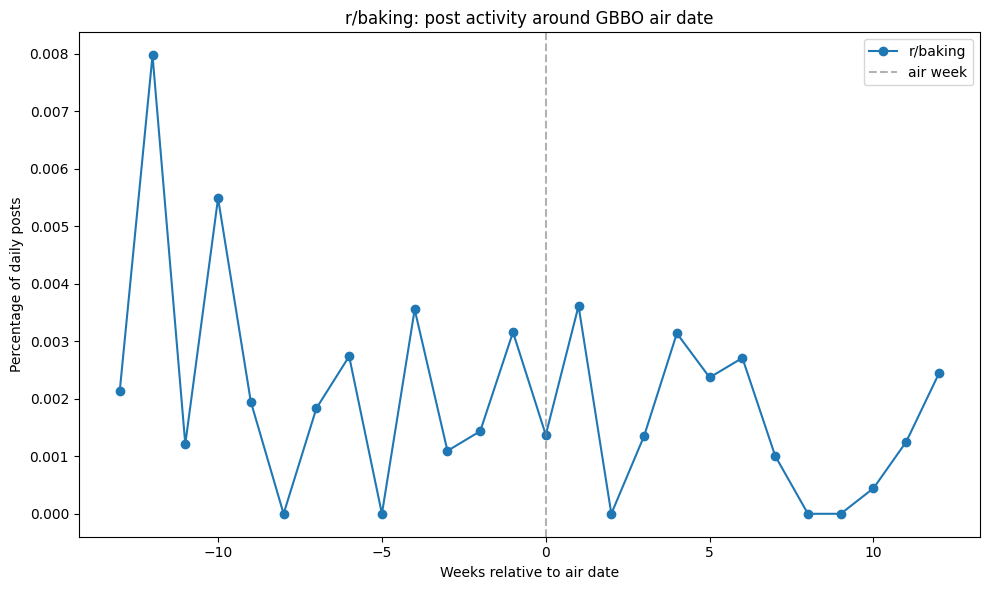

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(baking_weekly['week_bucket'], baking_weekly['share']*100, marker='o', label='r/baking')

ax.axvline(0, color='gray', linestyle='--', alpha=0.6, label='air week')

ax.set_xlabel('Weeks relative to air date')
ax.set_ylabel('Percentage of daily posts')
ax.set_title('r/baking: post activity around GBBO air date')
ax.legend()

plt.tight_layout()
plt.show()